# Extract features from transfer learning

In [2]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage
import skimage.io
import tifffile

import time
import torch
import torch.hub
import torch.nn

from alias_multinomial import AliasMethod
from utils_eval import NCESoftmaxLoss, NCECriterion
from MicNet_model import *

/project/DPDS/Xiao_lab/shared/qin_zhou/environments/envs/MicNet/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1) Load data

(25219, 27482, 3)


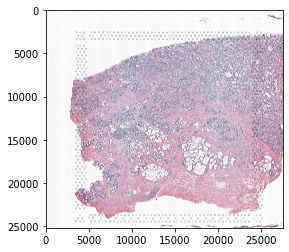

In [3]:
image_file = "./Sample_data/Dataset_HPC/Visium_FFPE_Human_Prostate_Cancer_image.tif"
image = tifffile.imread(os.path.join(image_file))
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [4]:
count_stat = pd.read_csv("./output/Dataset_HPC/1_count_stat_prostate.csv", index_col=0)
count = pd.read_csv("./output/Dataset_HPC/1_pd_count_norm_prostate.csv", index_col=0)

In [15]:
transformation_file = "./output/Dataset_HPC/location_prostate_cancer.csv"
pd_meta = pd.read_table(transformation_file, index_col=0, sep=",")
print(pd_meta.shape)


(4371, 2)


In [8]:
# Split training and testing
np.random.seed(12345)
indexes_all = pd_meta.index.values.copy()
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.8), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3496, #Testing: 875


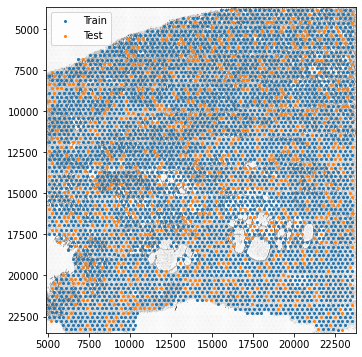

In [9]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm[..., 0], cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Y"].values
coords_y = pd_meta.loc[training_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Y"].values
coords_y = pd_meta.loc[testing_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")

coords_x = pd_meta.loc[:, "Y"].values
coords_y = pd_meta.loc[:, "X"].values

plt.gca().set_aspect('equal')
xmin = np.min(pd_meta.loc[:, "Y"] - 200)
xmax = np.max(pd_meta.loc[:, "Y"] + 200)
ymin = np.min(pd_meta.loc[:, "X"] - 200)
ymax = np.max(pd_meta.loc[:, "X"] + 200)
plt.xlim(xmin, xmax)
plt.ylim(ymax, ymin)
# plt.xlim(0, image.shape[1])
# plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [10]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [11]:
count

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
AAACAAGTATCTCCCA-1,0.0,0.0,0.660738,0.0,0.0,0.692662,0.0,0.000000,0.715411,0.0,...,0.000000,0.000000,0.0,0.0,0.728694,0.000000,0.000000,0.000000,0.722012,0.875171
AAACACCAATAACTGC-1,0.0,0.0,0.715257,0.0,0.0,0.725529,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.653642,0.000000,0.772156,0.733011,0.612304
AAACAGAGCGACTCCT-1,0.0,0.0,0.588620,0.0,0.0,0.606604,0.0,0.589274,0.000000,0.0,...,0.000000,0.606708,0.0,0.0,0.805140,0.000000,0.000000,0.645587,0.489945,0.821919
AAACAGCTTTCAGAAG-1,0.0,0.0,0.820626,0.0,0.0,0.612947,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.750048,0.640600,0.718250,0.652339,0.623321,0.698001
AAACAGGGTCTATATT-1,0.0,0.0,0.854723,0.0,0.0,0.000000,0.0,0.686329,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.827889,0.000000,0.570640,0.691689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0.0,0.0,0.748681,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.638981,0.0,0.0,0.000000,0.667694,0.000000,0.679929,0.644452,0.625467
TTGTTTCACATCCAGG-1,0.0,0.0,0.768762,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.731706,0.662859,0.0,0.0,0.697221,0.692644,0.000000,0.705336,0.616325,0.648839
TTGTTTCATTAGTCTA-1,0.0,0.0,0.000000,0.0,0.0,0.773351,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.624625,0.000000
TTGTTTCCATACAACT-1,0.0,0.0,0.827904,0.0,0.0,0.000000,0.0,0.737971,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.694918,0.000000


In [12]:
PATCH_SIZE = 256

# 2) Check data loader

In [13]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

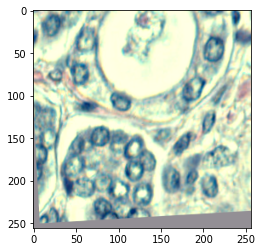

tensor([1270])


In [14]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

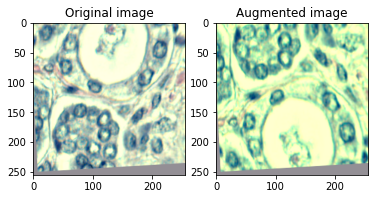

In [15]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

# 3) Create network

In [17]:
from torch.nn.modules import MSELoss
from utils_eval import NCESoftmaxLoss, NCECriterion


device = torch.device("cuda:0")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters

nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters

lr = 0.01   # ori 0.01
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/s223242/.cache/torch/hub/pytorch_vision_v0.4.0


In [5]:
model_dir = "./models/Dataset_HPC"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

# Inference

In [10]:
"""TO LOAD:"""

model_file = os.path.join(model_dir, "epoch_best.pt")
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

=> loading checkpoint './models/Dataset_HPC/epoch_best.pt'


In [34]:
test_set = Dataset(indexes_all, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

In [38]:
model.eval()

with torch.no_grad():
    for idx, (data, index) in enumerate(test_loader):
        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])

In [39]:
image_feature = feat_images
gene_feature = feat_genes

In [40]:
# Save result
torch.save([feat_images, feat_genes], "./output/Dataset_HPC/3_IGC_prostate.pt")

# Read Ground truth

In [20]:
GT_raw=pd.read_csv('./Sample_data/Dataset_HPC/Pathology.csv',index_col=0,sep=',')
GT_raw

,Pathology
Barcode,
AAACAAGTATCTCCCA-1,Normal gland
AAACACCAATAACTGC-1,Normal gland
AAACAGAGCGACTCCT-1,Invasive carcinoma
AAACAGCTTTCAGAAG-1,Normal gland
AAACAGGGTCTATATT-1,Normal gland
...,...
TTGTTGTGTGTCAAGA-1,NaN
TTGTTTCACATCCAGG-1,Normal gland
TTGTTTCATTAGTCTA-1,Fibro-muscular tissue


In [21]:
pd_meta

,X,Y
AAACAAGTATCTCCCA-1,16467,19883
AAACACCAATAACTGC-1,18720,7839
AAACAGAGCGACTCCT-1,7378,18737
AAACAGCTTTCAGAAG-1,14679,6394
AAACAGGGTCTATATT-1,15690,6973
...,...,...
TTGTTGTGTGTCAAGA-1,11665,16264
TTGTTTCACATCCAGG-1,18473,11176
TTGTTTCATTAGTCTA-1,18975,9434
TTGTTTCCATACAACT-1,15188,9005


# Clustering

In [22]:
feat_images, feat_genes = torch.load("./output/Dataset_HPC/3_IGC_prostate.pt")

image_feature = feat_images
gene_feature = feat_genes

In [23]:
import numpy as np
import pandas as pd

# Concatenate features
MicNet_embedding_array = np.concatenate((image_feature, gene_feature), axis=1)

# Convert to DataFrame and add GT_raw index
MicNet_embedding = pd.DataFrame(MicNet_embedding_array, index=GT_raw.index)


In [25]:
def run_clustering(method, embedding, index, label_name, gt=None):
    # mask out NaN rows
    mask_x = ~np.any(np.isnan(embedding), axis=1)
    Xf = embedding[mask_x]

    # run clustering
    labels = method.fit_predict(Xf)

    # create full-length prediction vector
    y_pred_full = np.full(embedding.shape[0], np.nan)
    y_pred_full[mask_x] = labels

    # wrap into DataFrame
    df = pd.DataFrame({label_name: y_pred_full}, index=index)

    # if gt provided, compute ARI directly
    if gt is not None:
        mask_common = ~df[label_name].isna() & gt.notna()
        ari = adjusted_rand_score(gt[mask_common], df[label_name][mask_common].astype(int))
        return df, ari

    return df


In [26]:
from sklearn.cluster import KMeans

n_clusters = 7

method = KMeans(init='k-means++', n_clusters=n_clusters, n_init=50, max_iter=500, random_state=0)

MicNet_df        = run_clustering(method, MicNet_embedding.to_numpy(), MicNet_embedding.index, "label")

In [27]:
import numpy as np
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Ground truth
gt = GT_raw['Pathology']

# Dictionary of prediction dataframes
pred_dfs = {
    "MicNet": MicNet_df,
}

# Store results
scores = {}

for name, df in pred_dfs.items():
    # pick the right label column
    if "label" in df.columns:
        Y = df['label'].to_numpy()
    elif "cluster" in df.columns:
        Y = df['cluster'].to_numpy()
    else:
        raise ValueError(f"{name} dataframe missing label column")

    # Masks: keep only samples with both predictions and GT
    mask_pred = ~np.isnan(Y)
    mask_gt   = gt.notna().to_numpy()
    mask_common = mask_pred & mask_gt

    y_true = gt.to_numpy()[mask_common]
    y_pred = Y[mask_common].astype(int)

    # Compute ARI and AMI
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    scores[name] = {"ARI": ari, "AMI": ami, "n_samples": mask_common.sum()}

# Print results
for name, score in scores.items():
    print(f"{name}: ARI={score['ARI']:.4f}, AMI={score['AMI']:.4f} (n={score['n_samples']})")


MicNet: ARI=0.4728, AMI=0.4544 (n=3760)
